# Customer Lifetime Value (LTV) Modeling

## Objective

Estimate the expected future lifetime value of active customers using survival analysis and current monthly charges.

In [15]:
import pandas as pd
df=pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40


In [16]:
df.shape

(7043, 22)

In [17]:
df[["CustomerID", "Tenure", "Churn", "MonthlyCharges"]].head()

,CustomerID,Tenure,Churn,MonthlyCharges
0,7590-VHVEG,1,No,29.85
1,5575-GNVDE,34,No,56.95
2,3668-QPYBK,2,Yes,53.85
3,7795-CFOCW,45,No,42.30
4,9237-HQITU,2,Yes,70.70


In [18]:
df[["Tenure", "MonthlyCharges"]].dtypes

Tenure              int64
MonthlyCharges    float64
dtype: object

In [19]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Survival Analysis Preparation

For survival analysis:
- Tenure represents the observed duration.
- Churn indicates whether the churn event occurred.
- Active customers are treated as censored observations.

In [21]:
survival_df = df[["Tenure", "Churn"]].copy()
survival_df["event"] = (survival_df["Churn"] == "Yes").astype(int)

survival_df.head()

,Tenure,Churn,event
0,1,No,0
1,34,No,0
2,2,Yes,1
3,45,No,0
4,2,Yes,1


In [22]:
survival_df["event"].value_counts()

event
0    5174
1    1869
Name: count, dtype: int64

In [24]:
%pip install lifelines

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.1 MB 14.6 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.1 MB 14.8 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.1 MB 9.3 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.1 MB 8.3 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 7.1 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.1 MB 6.5 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.1 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.1 MB 5.7

  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
#Lifelines: a Python library designed for survival analysis.
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["Tenure"],
    event_observed=survival_df["event"]
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 7043 total observations, 5174 right-censored observations>

In [27]:
kmf.survival_function_.head()

,KM_estimate
timeline,
0.0,1.000000
1.0,0.945961
2.0,0.927835
3.0,0.913725
4.0,0.901045


- timeline = tenure
- KM_estimate = estimated probability of a customer surviving beyond that point

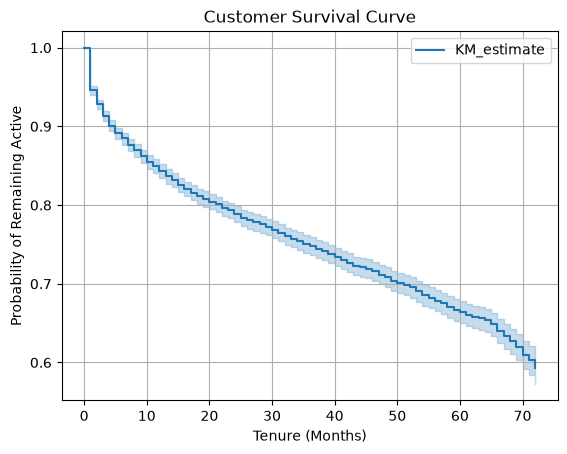

In [28]:
import matplotlib.pyplot as plt

kmf.plot_survival_function()

plt.title("Customer Survival Curve")
plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining Active")
plt.grid(True)
plt.show()

In [29]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'LTV'],
      dtype='str')

In [30]:
cox_df = df.drop(
    ["CustomerID", "Tenure", "Churn", "TotalCharges", "LTV"],
    axis=1
).copy()

cox_df["Tenure"] = df["Tenure"]
cox_df["event"] = (df["Churn"] == "Yes").astype(int)

cox_df.head()

,Gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Tenure,event
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,1,0
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,34,0
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,2,1
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,45,0
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,2,1


In [31]:
cox_df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Tenure', 'event'],
      dtype='str')

In [33]:
categorical_features = cox_df.select_dtypes(include="str").columns

categorical_features

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')